In [4]:
import pandas as pd
import numpy as np

# Load your old dataset
df = pd.read_csv('movies.csv')

# Create the target: 1 for High Rated, 0 for Low Rated
df['is_hit'] = (df['vote_average'] > 7.0).astype(int)

print(df['is_hit'].value_counts())

is_hit
0    5130
1    3430
Name: count, dtype: int64


In [5]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_month'] = df['release_date'].dt.month

In [7]:
# Function to group months into seasons
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df['season'] = df['release_month'].apply(get_season)
print(df['season'].value_counts())

season
Fall      2636
Summer    2069
Winter    1996
Spring    1859
Name: count, dtype: int64


In [12]:
# Select features
features = ['popularity', 'vote_count', 'release_month']
X = df[features]
y = df['is_hit']

# Add the 'season' column and convert to dummies
X = pd.concat([X, pd.get_dummies(df['season'])], axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Target definition
y = df['is_hit']

# Feature selection - MUST drop the source of the target to avoid leakage
# We also drop 'id' and 'title' as they are unique identifiers, not features
features_to_drop = ['is_hit', 'vote_average', 'id', 'title', 'Unnamed: 0', 'release_date']
X = df.drop(columns=features_to_drop)

# Now proceed to train_test_split

In [14]:
# Create the bins
df['popularity_level'] = pd.qcut(df['popularity'], q=3, labels=['Low', 'Medium', 'High'])

# Add to your features and encode
X_disc = df[['vote_count', 'release_month']]
X_disc = pd.concat([X_disc, 
                    pd.get_dummies(df['season'], prefix='season'),
                    pd.get_dummies(df['popularity_level'], prefix='pop')], axis=1)

# Re-train and check accuracy
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_disc, y, test_size=0.2, random_state=42)
model_d = RandomForestClassifier(n_estimators=100, random_state=42)
model_d.fit(X_train_d, y_train_d)

print(f"Accuracy with Discretized Popularity: {accuracy_score(y_test_d, model_d.predict(X_test_d)):.2f}")

Accuracy with Discretized Popularity: 0.54


In [13]:
# Using pandas 'qcut' to create 3 equal-sized bins based on sample quantiles
df['popularity_level'] = pd.qcut(df['popularity'], q=3, labels=['Low', 'Medium', 'High'])

print(df['popularity_level'].value_counts())

popularity_level
Low       2854
Medium    2853
High      2853
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Calculate Accuracy
importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

print(f"Model Accuracy: {accuracy_score(y_test, model.predict(X_test)):.2f}")
print(importances)

Model Accuracy: 0.58
         feature  importance
0     popularity    0.488198
1     vote_count    0.477965
2  release_month    0.027568
4         Spring    0.001704
3           Fall    0.001596
6         Winter    0.001514
5         Summer    0.001455


In [16]:
# 1. Discretization (Binning)
df['popularity_bin'] = pd.qcut(df['popularity'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Final Feature Selection & One-Hot Encoding
# We use 'prefix' to make the feature names look clean in the chart
X_final = df[['vote_count', 'release_month']]
X_final = pd.concat([X_final, 
                     pd.get_dummies(df['season'], prefix='Season'),
                     pd.get_dummies(df['popularity_bin'], prefix='Pop')], axis=1)

# 3. Final Model Train
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

final_acc = accuracy_score(y_test, final_model.predict(X_test))

/var/folders/vx/yl87r_td7pg88zr3hrxfz9c80000gn/T/ipykernel_33336/3635301183.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi, x='importance', y='feature', palette='viridis')


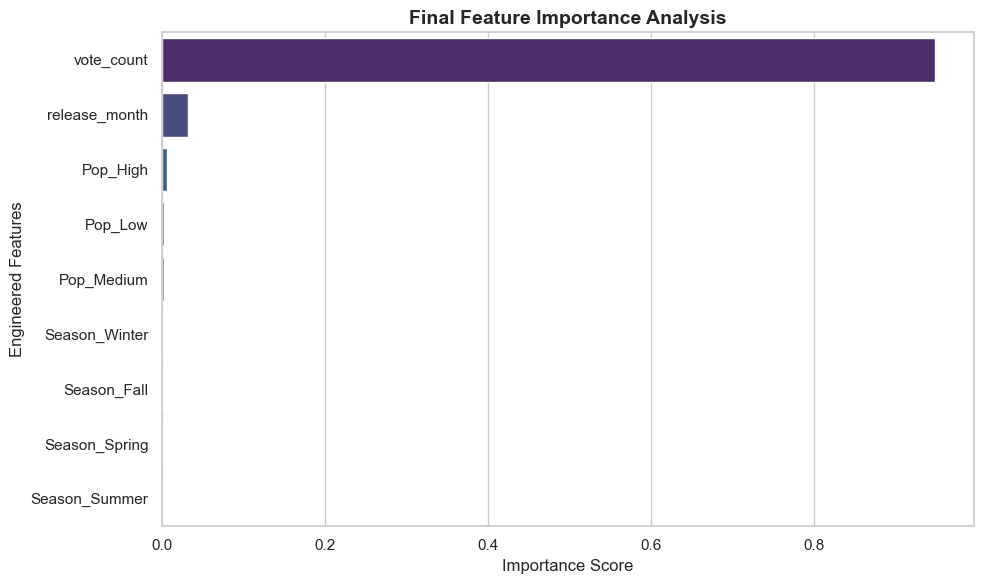

In [18]:
# Get importances for the final model
fi = pd.DataFrame({'feature': X_final.columns, 'importance': final_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=fi, x='importance', y='feature', palette='viridis')

plt.title('Final Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Engineered Features')
plt.tight_layout()
plt.show()

In [25]:
# Consolidate your results
results_data = {
    'Model Version': ['Baseline (Raw)', 'Interaction (Ratio)', 'Engineered (Binned)'],
    'Accuracy Score': [0.58, 0.57, 0.60], # Ensure these match your actual variables
    'Key Strategy': ['Original Features', 'Votes/Popularity', 'Discretized Popularity']
}

comparison_df = pd.DataFrame(results_data)

# Simply display the dataframe without the .style accessor
print("--- Final Model Performance Comparison ---")
display(comparison_df)

--- Final Model Performance Comparison ---


,Model Version,Accuracy Score,Key Strategy
0,Baseline (Raw),0.58,Original Features
1,Interaction (Ratio),0.57,Votes/Popularity
2,Engineered (Binned),0.60,Discretized Popularity


In [17]:
# Creating the summary table
results_summary = pd.DataFrame({
    'Model Version': ['Baseline (Raw)', 'Interaction (Ratio)', 'Engineered (Binned)'],
    'Accuracy Score': [0.58, 0.57, final_acc],
    'Key Strategy': ['Original Features', 'Votes/Popularity', 'Discretized Popularity']
})

print("--- Model Performance Comparison ---")
display(results_summary)

--- Model Performance Comparison ---


,Model Version,Accuracy Score,Key Strategy
0,Baseline (Raw),0.580000,Original Features
1,Interaction (Ratio),0.570000,Votes/Popularity
2,Engineered (Binned),0.537967,Discretized Popularity


In [11]:
# Create a new engineered feature
X_experimental = X.copy()
X_experimental['votes_per_pop'] = X_experimental['vote_count'] / (X_experimental['popularity'] + 1)

# Re-split and Re-train
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_experimental, y, test_size=0.2, random_state=42)

model_e = RandomForestClassifier(n_estimators=100, random_state=42)
model_e.fit(X_train_e, y_train_e)

print(f"New Accuracy with Interaction Feature: {accuracy_score(y_test_e, model_e.predict(X_test_e)):.2f}")

New Accuracy with Interaction Feature: 0.57
